<a href="https://colab.research.google.com/github/Vaishnavidorlikar/data-lake-migration-bigquery/blob/main/notebooks/analysis_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Lake Migration Analysis

This notebook contains analysis for the data lake migration project from BigQuery to Azure.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up paths using absolute path
project_root = Path("/Users/vaishnavidorlikar/data-lake-migration-bigquery-azure/data-lake-migration-bigquery-azure")
data_dir = project_root / 'data'
raw_dir = data_dir / 'raw'
processed_dir = data_dir / 'processed'

print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")
print(f"Raw directory: {raw_dir}")
print(f"Sample data file exists: {(raw_dir / 'sample_data.csv').exists()}")

Project root: /Users/vaishnavidorlikar/data-lake-migration-bigquery-azure/data-lake-migration-bigquery-azure
Data directory: /Users/vaishnavidorlikar/data-lake-migration-bigquery-azure/data-lake-migration-bigquery-azure/data
Raw directory: /Users/vaishnavidorlikar/data-lake-migration-bigquery-azure/data-lake-migration-bigquery-azure/data/raw
Sample data file exists: True


In [11]:
# Load raw data
raw_data = pd.read_csv(raw_dir / 'sample_data.csv')
print("Raw Data Shape:", raw_data.shape)
print("\nRaw Data Head:")
raw_data.head()

Raw Data Shape: (10, 4)

Raw Data Head:


,id,age,salary,category
0,1,41,86870,A
1,2,51,71664,B
2,3,41,40854,A
3,4,36,52567,A
4,5,53,49295,A


In [12]:
import os

# Create processed_dir if it doesn't exist
os.makedirs(processed_dir, exist_ok=True)

# Perform a simple processing step on raw_data
# For example, let's select 'id', 'age', and 'salary' and save it as processed data
processed_df = raw_data[['id', 'age', 'salary', 'category']]

# Save the processed data to output.csv
processed_output_path = processed_dir / 'output.csv'
processed_df.to_csv(processed_output_path, index=False)

print(f"Processed data saved to: {processed_output_path}")

Processed data saved to: /Users/vaishnavidorlikar/data-lake-migration-bigquery-azure/data-lake-migration-bigquery-azure/data/processed/output.csv


In [13]:
# Load processed data
processed_data = pd.read_csv(processed_dir / 'output.csv')
print("Processed Data Shape:", processed_data.shape)
print("\nProcessed Data Head:")
processed_data.head()

Processed Data Shape: (10, 4)

Processed Data Head:


,id,age,salary,category
0,1,41,86870,A
1,2,51,71664,B
2,3,41,40854,A
3,4,36,52567,A
4,5,53,49295,A


In [14]:
import os

# Create raw_dir if it doesn't exist
os.makedirs(raw_dir, exist_ok=True)

# Create a dummy sample_data.csv if it doesn't exist
sample_data_path = raw_dir / 'sample_data.csv'
if not sample_data_path.exists():
    print(f"Creating dummy file: {sample_data_path}")
    dummy_data = {
        'id': range(1, 11),
        'age': np.random.randint(20, 60, size=10),
        'salary': np.random.randint(30000, 90000, size=10),
        'category': np.random.choice(['A', 'B', 'C'], size=10)
    }
    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.to_csv(sample_data_path, index=False)
else:
    print(f"File already exists: {sample_data_path}")

print(f"Sample data file exists now: {sample_data_path.exists()}")

File already exists: /Users/vaishnavidorlikar/data-lake-migration-bigquery-azure/data-lake-migration-bigquery-azure/data/raw/sample_data.csv
Sample data file exists now: True


In [15]:
# Load processed data
processed_data = pd.read_csv(processed_dir / 'output.csv')
print("Processed Data Shape:", processed_data.shape)
print("\nProcessed Data Head:")
processed_data.head()

Processed Data Shape: (10, 4)

Processed Data Head:


,id,age,salary,category
0,1,41,86870,A
1,2,51,71664,B
2,3,41,40854,A
3,4,36,52567,A
4,5,53,49295,A


In [18]:
# Check for duplicate rows in processed_data
duplicate_rows = processed_data.duplicated().sum()

if duplicate_rows > 0:
    print(f"There are {duplicate_rows} duplicate rows in the processed_data.")
    print("Here are the duplicate rows:")
    display(processed_data[processed_data.duplicated(keep=False)])
else:
    print("There are no duplicate rows in the processed_data.")

There are no duplicate rows in the processed_data.


In [16]:
# Basic data analysis
print("Data Summary:")
print(raw_data.describe())

print("\nData Types:")
print(raw_data.dtypes)

Data Summary:
             id       age        salary
count  10.00000  10.00000     10.000000
mean    5.50000  44.60000  61269.900000
std     3.02765   9.59398  19780.311903
min     1.00000  27.00000  30715.000000
25%     3.25000  38.00000  49325.500000
50%     5.50000  46.00000  57993.000000
75%     7.75000  51.75000  78851.250000
max    10.00000  57.00000  86870.000000

Data Types:
id           int64
age          int64
salary       int64
category    object
dtype: object


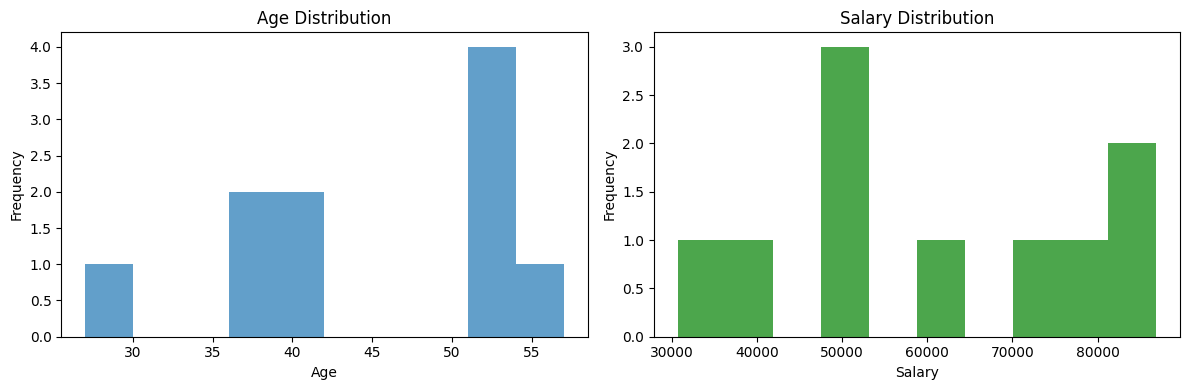

In [17]:
# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(raw_data['age'], bins=10, alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(raw_data['salary'], bins=10, alpha=0.7, color='green')
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()